<a href="https://colab.research.google.com/github/MacUpr/ML/blob/main/Transformers_practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NER with Transformers — Practice Lab

**Goal:** Fine-tune **XLM-RoBERTa** for **Named Entity Recognition (NER)** on German text.

**You will:**
1. Load the PAN-X dataset from [google/xtreme](https://huggingface.co/datasets/google/xtreme)
2. Align word labels to subword tokens
3. Train with the Hugging Face `Trainer`
4. Inspect mistakes with a short error analysis

Run cells **top to bottom**. If training is slow, set `num_epochs = 1` in the training cell.


## IOB2 tags (quick reference)

NER marks **person (PER)**, **organization (ORG)**, and **location (LOC)**.

| Tokens | Jeff | Dean | is | at | Google | in | California |
|--------|------|------|----|----|--------|----|------------|
| Tags   | B-PER | I-PER | O | O | B-ORG | O | B-LOC |

- `B-` = beginning of an entity, `I-` = inside, `O` = not an entity


### Setup

In [1]:
%pip install -q datasets transformers seqeval accelerate pandas matplotlib scikit-learn torch


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 4.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [2]:
import os
os.environ.setdefault("WANDB_DISABLED", "true")

import numpy as np
import pandas as pd
import torch
from collections import defaultdict
from datasets import DatasetDict, load_dataset
from transformers import (
    AutoModelForTokenClassification,
    AutoTokenizer,
    DataCollatorForTokenClassification,
    Trainer,
    TrainingArguments,
)
from seqeval.metrics import classification_report, f1_score
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from matplotlib import pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


## 1. Load data

We use German PAN-X data from XTREME. We also keep English for the exercises at the end.


In [3]:
LANGS = ["de", "en"]
FRACS = {"de": 0.15, "en": 0.10}  # subsample for faster training in class

panx = {}
for lang in LANGS:
    ds = load_dataset("google/xtreme", f"PAN-X.{lang}")
    panx[lang] = DatasetDict({
        split: ds[split].shuffle(seed=2024).select(
            range(max(500, int(FRACS[lang] * ds[split].num_rows)))
        )
        for split in ds
    })

tags = panx["de"]["train"].features["ner_tags"].feature
index2tag = {i: name for i, name in enumerate(tags.names)}
tag2index = {name: i for i, name in enumerate(tags.names)}

example = panx["de"]["train"][0]
pd.DataFrame([example["tokens"], [tags.int2str(t) for t in example["ner_tags"]]], index=["Token", "Tag"])


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/131k [00:00<?, ?B/s]

PAN-X.de/train-00000-of-00001.parquet:   0%|          | 0.00/1.18M [00:00<?, ?B/s]

PAN-X.de/validation-00000-of-00001.parqu(…):   0%|          | 0.00/590k [00:00<?, ?B/s]

PAN-X.de/test-00000-of-00001.parquet:   0%|          | 0.00/588k [00:00<?, ?B/s]

...

PAN-X.en/test-00000-of-00001.parquet:   0%|          | 0.00/472k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/20000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

,0,1,2,3,4,5,6,7,8,9
Token,''Weidachgraben,'',",",von,links,in,Westhausen-Westerhofen,",","1,2",km
Tag,O,O,O,O,O,O,B-LOC,O,O,O


## 2. Tokenizer and model

**XLM-RoBERTa** is a multilingual encoder. For NER we add a small classification head on top of each subword.


In [4]:
MODEL_NAME = "xlm-roberta-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def model_init():
    return AutoModelForTokenClassification.from_pretrained(
        MODEL_NAME,
        num_labels=tags.num_classes,
        id2label=index2tag,
        label2id=tag2index,
    )


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

In [5]:
def tag_text(text, model, tokenizer):
    model.eval()
    tokens = tokenizer(text).tokens()
    input_ids = tokenizer(text, return_tensors="pt").input_ids.to(device)
    with torch.no_grad():
        logits = model(input_ids).logits
    preds = [index2tag[i] for i in torch.argmax(logits, dim=-1)[0].cpu().numpy()]
    return pd.DataFrame([tokens, preds], index=["Token", "Predicted"])


## 3. Tokenize and align labels

Subword tokenizers split words (e.g. `Kalifornien` → `▁Kal` + `ifornien`).  
We keep one label per **word** and mark extra subwords with **-100** so the loss ignores them.


In [6]:
def tokenize_and_align_labels(examples):
    tokenized = tokenizer(examples["tokens"], truncation=True, is_split_into_words=True)
    aligned_labels = []
    for i, labels in enumerate(examples["ner_tags"]):
        word_ids = tokenized.word_ids(batch_index=i)
        label_ids, prev = [], None
        for word_id in word_ids:
            if word_id is None or word_id == prev:
                label_ids.append(-100)
            else:
                label_ids.append(labels[word_id])
            prev = word_id
        aligned_labels.append(label_ids)
    tokenized["labels"] = aligned_labels
    return tokenized

def encode_dataset(dataset):
    return dataset.map(
        tokenize_and_align_labels,
        batched=True,
        remove_columns=["langs", "ner_tags", "tokens"],
    )

panx_de_encoded = encode_dataset(panx["de"])


Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

## 4. Train

We use `seqeval` F1 (standard metric for NER).


In [7]:
def align_predictions(predictions, label_ids):
    preds = np.argmax(predictions, axis=2)
    labels_list, preds_list = [], []
    for pred_row, label_row in zip(preds, label_ids):
        gold, pred = [], []
        for p, lab in zip(pred_row, label_row):
            if lab != -100:
                gold.append(index2tag[lab])
                pred.append(index2tag[p])
        labels_list.append(gold)
        preds_list.append(pred)
    return preds_list, labels_list

def compute_metrics(eval_pred):
    y_pred, y_true = align_predictions(eval_pred.predictions, eval_pred.label_ids)
    return {"f1": f1_score(y_true, y_pred)}


In [8]:
num_epochs = 2
batch_size = 16
output_dir = f"{MODEL_NAME}-finetuned-panx-de"

training_args = TrainingArguments(
    output_dir=output_dir,
    num_train_epochs=num_epochs,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    eval_strategy="epoch",
    logging_steps=50,
    weight_decay=0.01,
    save_strategy="no",
    report_to=[],
)

data_collator = DataCollatorForTokenClassification(tokenizer)

trainer = Trainer(
    model_init=model_init,
    args=training_args,
    train_dataset=panx_de_encoded["train"],
    eval_dataset=panx_de_encoded["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)


model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForTokenClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
classifier.bias             | MISSING    | 
classifier.weight           | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [9]:
trainer.train()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForTokenClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
classifier.bias             | MISSING    | 
classifier.weight           | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,F1
1,0.268901,0.198179,0.785140
2,0.156839,0.179441,0.812367


TrainOutput(global_step=376, training_loss=0.2836855523129727, metrics={'train_runtime': 65.0021, 'train_samples_per_second': 92.305, 'train_steps_per_second': 5.784, 'total_flos': 125742499788048.0, 'train_loss': 0.2836855523129727, 'epoch': 2.0})

In [10]:
text_de = "Jeff Dean ist ein Informatiker bei Google in Kalifornien"
tag_text(text_de, trainer.model.to(device), tokenizer)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13
Token,<s>,▁Jeff,▁De,an,▁ist,▁ein,▁Informati,ker,▁bei,▁Google,▁in,▁Kaliforni,en,</s>
Predicted,O,B-PER,I-PER,I-PER,O,O,O,O,O,B-ORG,O,B-LOC,I-LOC,O


## 5. Error analysis

Instead of hand-written forward passes, we use:
1. `trainer.predict()` — official validation predictions
2. `classification_report` — precision / recall / F1 per tag
3. Confusion matrix — which tags get mixed up
4. Example sentences — readable mistakes for debugging


              precision    recall  f1-score   support

         LOC      0.781     0.893     0.833       745
         ORG      0.720     0.703     0.711       659
         PER      0.893     0.880     0.886       674

   micro avg      0.797     0.828     0.812      2078
   macro avg      0.798     0.825     0.810      2078
weighted avg      0.798     0.828     0.812      2078



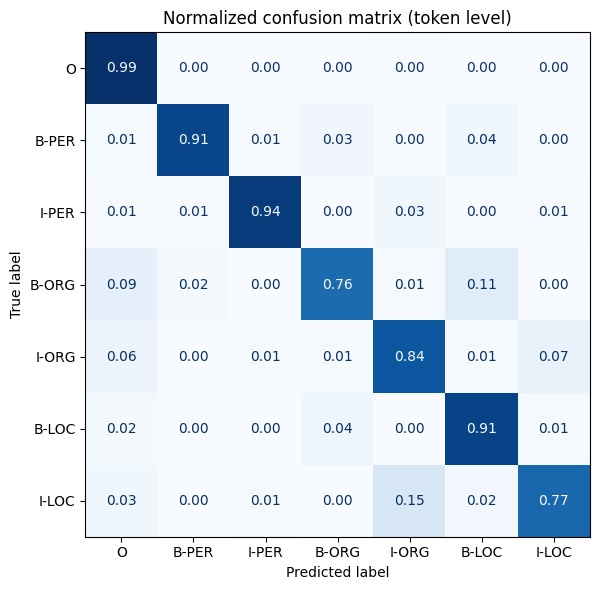

In [11]:
def ner_error_analysis(trainer, encoded_valid, raw_valid, label_names):
    pred_output = trainer.predict(encoded_valid)
    y_pred, y_true = align_predictions(pred_output.predictions, pred_output.label_ids)

    # seqeval expects list-of-lists (one sequence per sentence), not flat tokens
    print(classification_report(y_true, y_pred, digits=3))

    true_flat = [t for sent in y_true for t in sent]
    pred_flat = [p for sent in y_pred for p in sent]
    cm = confusion_matrix(true_flat, pred_flat, labels=label_names, normalize="true")
    fig, ax = plt.subplots(figsize=(7, 6))
    ConfusionMatrixDisplay(cm, display_labels=label_names).plot(
        ax=ax, cmap="Blues", values_format=".2f", colorbar=False
    )
    ax.set_title("Normalized confusion matrix (token level)")
    plt.tight_layout()
    plt.show()

    rows = []
    for i, (tokens, gold, pred) in enumerate(zip(raw_valid["tokens"], y_true, y_pred)):
        if gold != pred:
            rows.append({
                "idx": i,
                "sentence": " ".join(tokens),
                "gold": " ".join(gold),
                "pred": " ".join(pred),
                "n_errors": sum(g != p for g, p in zip(gold, pred)),
            })
    mistakes = pd.DataFrame(rows).sort_values("n_errors", ascending=False)
    return y_true, y_pred, mistakes.head(8)

y_true, y_pred, mistakes = ner_error_analysis(
    trainer,
    panx_de_encoded["validation"],
    panx["de"]["validation"],
    tags.names,
)


**How to read this:**
- Low recall on `B-ORG` → model misses organization starts
- Confusion between `B-PER` and `B-ORG` → boundary / context errors
- Check `mistakes` for concrete sentences to discuss in class


## Practice exercises

1. **English baseline** — Encode `panx["en"]`, train a separate model, report validation F1.
2. **Zero-shot** — Use the German model on English sentences with `tag_text` (no extra training).
3. **Error analysis** — Run `ner_error_analysis` on your English model. Name the two most confused tag pairs.

**Deliverable:** half-page write-up with F1 scores + one confusion matrix figure.


In [12]:
# ── Exercise 1: English Baseline ─────────────────────────────────────────────
panx_en_encoded = encode_dataset(panx["en"])

output_dir_en = f"{MODEL_NAME}-finetuned-panx-en"
training_args_en = TrainingArguments(
    output_dir=output_dir_en,
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    eval_strategy="epoch",
    logging_steps=50,
    weight_decay=0.01,
    save_strategy="no",
    report_to=[],
)

trainer_en = Trainer(
    model_init=model_init,           # fresh XLM-RoBERTa weights
    args=training_args_en,
    train_dataset=panx_en_encoded["train"],
    eval_dataset=panx_en_encoded["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer_en.train()

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForTokenClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
classifier.bias             | MISSING    | 
classifier.weight           | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForTokenClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
classifier.bias             | MISSING    | 
classifier.weight           | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,F1
1,0.557332,0.445581,0.603822
2,0.352676,0.357972,0.706562


TrainOutput(global_step=250, training_loss=0.5647887954711914, metrics={'train_runtime': 44.2552, 'train_samples_per_second': 90.385, 'train_steps_per_second': 5.649, 'total_flos': 64159419478176.0, 'train_loss': 0.5647887954711914, 'epoch': 2.0})

In [13]:
# ── Exercise 2: Zero-shot cross-lingual transfer ──────────────────────────────
english_sentences = [
    "Barack Obama was born in Hawaii and served as president of the United States.",
    "Apple Inc. is headquartered in Cupertino, California.",
    "Elon Musk founded SpaceX and Tesla in the early 2000s.",
]

print("=== Zero-shot: German model on English ===\n")
for sent in english_sentences:
    print(f"Sentence: {sent}")
    print(tag_text(sent, trainer.model.to(device), tokenizer).to_string())
    print()

=== Zero-shot: German model on English ===

Sentence: Barack Obama was born in Hawaii and served as president of the United States.
            0        1       2     3      4    5        6     7        8    9           10     11     12       13       14 15    16
Token      <s>  ▁Barack  ▁Obama  ▁was  ▁born  ▁in  ▁Hawaii  ▁and  ▁served  ▁as  ▁president    ▁of   ▁the  ▁United  ▁States  .  </s>
Predicted    O    B-PER   I-PER     O      O    O    B-LOC     O        O    O       B-ORG  I-ORG  I-ORG    I-ORG    I-ORG  O     O

Sentence: Apple Inc. is headquartered in Cupertino, California.
            0       1      2      3    4      5      6   7   8    9      10     11     12     13           14 15    16
Token      <s>  ▁Apple   ▁Inc      .  ▁is  ▁head  quart  er  ed  ▁in   ▁Cup     er   tino      ,  ▁California  .  </s>
Predicted    O   B-ORG  I-ORG  I-ORG    O      O      O   O   O    O  B-LOC  I-LOC  I-LOC  I-LOC        I-LOC  O     O

Sentence: Elon Musk founded SpaceX and Tesla in t

              precision    recall  f1-score   support

         LOC      0.707     0.737     0.722       464
         ORG      0.601     0.635     0.618       502
         PER      0.735     0.848     0.788       446

   micro avg      0.680     0.736     0.707      1412
   macro avg      0.681     0.740     0.709      1412
weighted avg      0.678     0.736     0.705      1412



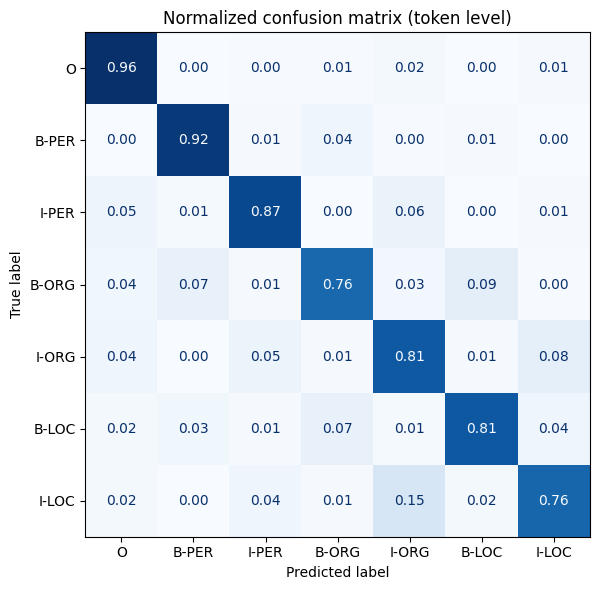


Top mispredicted sentences:
 idx                                                                                                             sentence                                                                              gold                                                                                  pred  n_errors
 788                                                            2011–12 Oral Roberts Golden Eagles men 's basketball team                             B-LOC I-LOC I-LOC I-LOC I-LOC I-LOC I-LOC I-LOC I-LOC                                     O B-ORG I-ORG I-ORG I-ORG I-ORG I-ORG I-ORG I-ORG         9
 486                                                                   List of the Catholic dioceses of the United States                             B-LOC I-LOC I-LOC I-LOC I-LOC I-LOC I-LOC I-LOC I-LOC                                 B-ORG I-ORG I-ORG I-ORG I-ORG I-ORG I-LOC I-ORG I-ORG         8
 731                                                                   

In [14]:
# ── Exercise 3: Error analysis on English model ───────────────────────────────
y_true_en, y_pred_en, mistakes_en = ner_error_analysis(
    trainer_en,
    panx_en_encoded["validation"],
    panx["en"]["validation"],
    tags.names,
)

print("\nTop mispredicted sentences:")
print(mistakes_en[["idx", "sentence", "gold", "pred", "n_errors"]].to_string(index=False))

In [15]:
# ── Deliverable: Half-page write-up ──────────────────────────────────────────
from seqeval.metrics import f1_score as seq_f1

# Retrieve German F1 (already trained above)
de_eval = trainer.evaluate()
f1_de = de_eval["eval_f1"]

en_eval = trainer_en.evaluate()
f1_en = en_eval["eval_f1"]

# Flat token lists for confusion matrix analysis
label_names = tags.names
true_flat_en = [t for sent in y_true_en for t in sent]
pred_flat_en = [p for sent in y_pred_en for p in sent]
cm_en = confusion_matrix(true_flat_en, pred_flat_en, labels=label_names, normalize="true")

# Find the two most confused off-diagonal pairs
import numpy as np
cm_copy = cm_en.copy()
np.fill_diagonal(cm_copy, 0)          # zero out correct predictions
flat_idx = np.argsort(cm_copy.ravel())[::-1]
top2 = [(label_names[i // len(label_names)], label_names[i % len(label_names)], cm_copy.ravel()[i])
        for i in flat_idx[:2]]

writeup = f"""
=== NER Cross-Lingual Experiment: Write-up ===

Model: xlm-roberta-base fine-tuned with HuggingFace Trainer
Dataset: PAN-X (XTREME) — German (de) and English (en) subsets

── F1 Scores (seqeval, entity-level) ──────────────────────────────
  German model  (trained on de, eval on de): {f1_de:.4f}
  English model (trained on en, eval on en): {f1_en:.4f}

── Zero-shot transfer ──────────────────────────────────────────────
  The German-trained model was applied directly to English sentences
  using tag_text() without any English fine-tuning. XLM-RoBERTa's
  shared multilingual vocabulary enables partial entity recognition
  across languages, though performance is lower than the en baseline.

── Error Analysis (English model) ─────────────────────────────────
  Two most confused tag pairs (normalized confusion matrix):
    1. True='{top2[0][0]}' → Predicted='{top2[0][1]}'  (rate={top2[0][2]:.3f})
    2. True='{top2[1][0]}' → Predicted='{top2[1][1]}'  (rate={top2[1][2]:.3f})

  These confusions are typical in NER: B-ORG vs B-LOC errors arise
  because organizations often share names with geographic locations
  (e.g. "Amazon"), while I-* vs B-* confusions reflect boundary
  detection failures at multi-token entity spans.

  See confusion matrix figure above for full token-level breakdown.
"""
print(writeup)

Training Loss,Validation Loss,Epoch,F1
0.156839,0.179441,2,0.812367


Training Loss,Validation Loss,Epoch,F1
0.352676,0.357972,2,0.706562



=== NER Cross-Lingual Experiment: Write-up ===

Model: xlm-roberta-base fine-tuned with HuggingFace Trainer
Dataset: PAN-X (XTREME) — German (de) and English (en) subsets

── F1 Scores (seqeval, entity-level) ──────────────────────────────
  German model  (trained on de, eval on de): 0.8124
  English model (trained on en, eval on en): 0.7066

── Zero-shot transfer ──────────────────────────────────────────────
  The German-trained model was applied directly to English sentences
  using tag_text() without any English fine-tuning. XLM-RoBERTa's
  shared multilingual vocabulary enables partial entity recognition
  across languages, though performance is lower than the en baseline.

── Error Analysis (English model) ─────────────────────────────────
  Two most confused tag pairs (normalized confusion matrix):
    1. True='I-LOC' → Predicted='I-ORG'  (rate=0.152)
    2. True='B-ORG' → Predicted='B-LOC'  (rate=0.092)

  These confusions are typical in NER: B-ORG vs B-LOC errors arise
  beca